In [ ]:
"""
Saved file contains a single dataset:
  - data: (T, H, W, n_ch) as float32, where n_ch=2 for WavePDE (u, v)
"""

from __future__ import annotations
from typing import Dict
import numpy as np
import h5py

from pde import ScalarField, CartesianGrid, MemoryStorage
from pde.pdes import WavePDE
from tqdm import tqdm


# # ===================== parameters =====================
# SPEED = 1/16           # wave speed, same as dino
# RESOLUTION = 64        # grid size, same as dino
# T_FINAL = 40.0         # total simulation time ,same as dino    
# NUM_FRAMES = 160       # number of snapshot saved, same as dino
# BATCH = 8                               
# BC = 'periodic'             
# OUT_PATH = 'wave_dataset.h5'



################################
# CONFIG — EDIT HERE ONLY      #
################################
CONFIG: Dict = {
    # Passed directly to WavePDE(**PDE)
    'PDE': {
        'speed': 1/16,
        'bc': 'periodic',
    },

    # Spatial grid
    'GRID': {
        'size': 64,                             # H = W = size
        'domain': [[-1.0, 1.0], [-1.0, 1.0]],   # computational domain per axis
        'periodic': True,                       # periodic BC like original
    },

    # Simulation timing
    'SIM': {
        't_horizon': 40.0,                      # total simulated time
        'dt': 0.25,                             # record interval (sampling)
        'internal_dt': 1e-3,                    # fixed stable step for solver
        'seed': 0,                              # RNG seed for reproducibility
        'n_samples': 16,
    },

    # Initial displacement u0 parameters
    'IC_U': {
        'radius': None,                         # dino: 0.25 + 0.05 * U[0,1)
        'amplitude': None,                      # dino: 2.0  + 2.0  * U[0,1)
        'roll': True,                           # same as dino, random shift
    },

    # Initial velocity v0
    'IC_V': {
        'mode': 'none',                         # 'none' (original behavior, v0=0) | 'gaussian'
        'gaussian': {
            'radius': 0.30,                     # for v0 when mode='gaussian'
            'amplitude': 0.50,
            'roll': True,
        },
    },

    # Output
    'OUTPUT': {
        'path': 'wave_dataset.h5',                 # HDF5 file; contains only dataset 'data'
        'dataset': 'data',
        'compression': None,                    # e.g. 'gzip' or None
    },
}


##############################
#           Helpers          #
##############################

def gaussian_bump(size: int, radius: float, amplitude: float, roll: bool, rng: np.random.Generator) -> np.ndarray:
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y, indexing='ij')
    dst2 = X * X + Y * Y
    u0 = amplitude * np.exp(-dst2 / (2.0 * radius * radius))
    if roll:
        shift0, shift1 = rng.integers(0, size, size=2)
        u0 = np.roll(u0, (int(shift0), int(shift1)), axis=(0, 1))
    return u0


def make_initial_state(grid: CartesianGrid, eq: WavePDE, cfg: Dict, rng: np.random.Generator):
    size = int(cfg['GRID']['size'])

    rad = cfg['IC_U']['radius']
    amp = cfg['IC_U']['amplitude']
    if rad is None:
        rad = 0.25 + 0.05 * rng.random()
    if amp is None:
        amp = 2.0  + 2.0  * rng.random()
    u0 = gaussian_bump(size,
                       radius=float(rad),
                       amplitude=float(amp),
                       roll=bool(cfg['IC_U']['roll']),
                       rng=rng)
    
    u = ScalarField(grid, u0)

    v = None
    v_mode = str(cfg['IC_V']['mode']).lower()
    if v_mode == 'none':
        v = None  # original behavior: v(·,0)=0
    elif v_mode == 'gaussian':
        g = cfg['IC_V']['gaussian']
        v0 = gaussian_bump(size,
                           radius=float(g['radius']),
                           amplitude=float(g['amplitude']),
                           roll=bool(g['roll']),
                           rng=rng)
        v = ScalarField(grid, v0)
    else:
        raise ValueError(f"Unknown IC_V.mode: {v_mode}")

    return eq.get_initial_condition(u) if v is None else eq.get_initial_condition(u, v)


def simulate_one(grid: CartesianGrid, eq: WavePDE, cfg: Dict, rng: np.random.Generator) -> np.ndarray:
    t_horizon = float(cfg['SIM']['t_horizon'])
    dt = float(cfg['SIM']['dt'])
    internal_dt = float(cfg['SIM']['internal_dt'])

    # initial states
    state0 = make_initial_state(grid, eq, cfg, rng)

    # Solve and sample into memory by dt (only the T frame of this sample)
    storage = MemoryStorage()
    eq.solve(state0, t_range=t_horizon, dt=internal_dt, tracker=storage.tracker(dt))

    # list -> array: (n_ch, T, H, W) -> (T, H, W, n_ch)
    arr = np.stack(storage.data, axis=1).astype(np.float32, copy=False)
    arr = np.transpose(arr, (1, 2, 3, 0))
    return arr


##############################
#            Core            #
##############################
def generate_and_save(cfg: Dict) -> None:
    # ---- RNG/ Grid/ Equation: Build once, reuse multiple times ----
    seed = cfg['SIM'].get('seed', None)
    rng = np.random.default_rng(seed)

    size = int(cfg['GRID']['size'])
    domain = cfg['GRID']['domain']
    periodic = bool(cfg['GRID']['periodic'])
    grid = CartesianGrid(domain, shape=size, periodic=periodic)
    eq = WavePDE(**cfg['PDE'])

    n_samples = int(cfg['SIM'].get('n_samples', 1))

    out_path = cfg['OUTPUT']['path']
    ds_name = cfg['OUTPUT'].get('dataset', 'data')
    compression = cfg['OUTPUT'].get('compression', None)

    # Run the first one first and get the shapes (T, H, W, n, ch).
    first = simulate_one(grid, eq, cfg, rng)
    T, H, W, n_ch = first.shape

    # Establish a dataset with growing batch dimension: (N, T, H, W, n ch)
    with h5py.File(out_path, 'w') as f:
        ds = f.create_dataset(
            ds_name,
            shape=(0, T, H, W, n_ch),                       # init N=0
            maxshape=(None, T, H, W, n_ch),                 # The N-axis can grow infinitely
            chunks=(1, T, H, W, n_ch),                      # Blocks written one by one
            compression=compression,
            # If use gzip, you can add the compression level: compression opts=4
        )

        # Write in the first one
        ds.resize(1, axis=0)
        ds[0] = first

        # Subsequent sample: append after each run, and only the "current one" will be retained in memory.
        for b in tqdm(range(1, n_samples)):
            arr = simulate_one(grid, eq, cfg, rng)
            ds.resize(b + 1, axis=0)
            ds[b] = arr


    print(f"Saved {n_samples} trajectories to {out_path} with shape (N={n_samples}, T={T}, H={H}, W={W}, n_ch={n_ch}).")


if __name__ == '__main__':
    generate_and_save(CONFIG)


100%|██████████| 15/15 [00:25<00:00,  1.71s/it]

Saved 16 trajectories to wave_dataset.h5 with shape (N=16, T=161, H=64, W=64, n_ch=2).


/tmp/ipykernel_2827146/3982569981.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


u shape: (161, 64, 64)
Wrote preview.gif


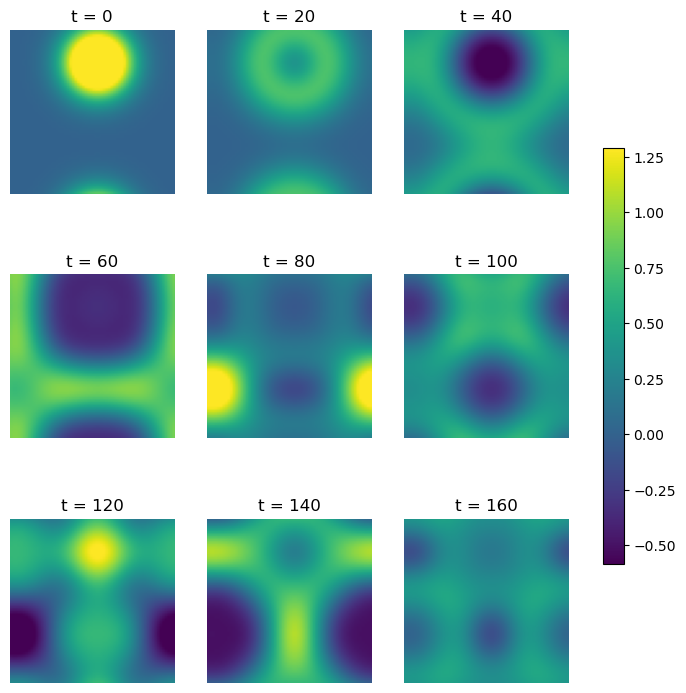

In [4]:
import h5py, numpy as np, matplotlib.pyplot as plt, imageio.v2 as imageio
import matplotlib.cm as cm
cmap = cm.get_cmap('viridis')

H5 = "wave_data.h5"
DS = "data"

with h5py.File(H5, "r") as f:
    arr = f[DS][...]

def get_slice(batch_data, idx=0):
    return batch_data[idx,...]

arr = get_slice(arr)

T, H, W, C = arr.shape
u = arr[..., 0]
print("u shape:", u.shape)   # (T, H, W)

# ---- 9 - grid preview (with automatic contrast cropping) ----
idx = np.linspace(0, T-1, 9, dtype=int)
vmin, vmax = np.percentile(u, (1, 99)) # for robustness
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, i in zip(axes.flat, idx):
    im = ax.imshow(u[i], vmin=vmin, vmax=vmax, origin="lower", cmap="viridis")
    ax.set_title(f"t = {i}")
    ax.axis("off")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)

frames = []
for i in range(T):
    # Normalize to [0,1], and use the same vmin/vmax to ensure color scale consistency
    norm = (u[i] - vmin) / (vmax - vmin + 1e-12)
    norm = np.clip(norm, 0, 1)

    # Map to RGB: cmap(...)" Return RGBA, take the first three channels and convert them to uint8
    rgb = (cmap(norm)[..., :3] * 255).astype(np.uint8)  # (H, W, 3)
    frames.append(rgb)

imageio.mimsave("preview.gif", frames, duration=0.04)  # 25 fps ≈ 0.04 seconds per frame
print("Wrote preview.gif")